# Energy Demand Data Pipeline

This notebook implements an end-to-end data wrangling pipeline that integrates U.S. energy consumption data with historical weather observations. The goal is to produce a clean, analysis-ready dataset that enables exploration of how temperature patterns drive energy demand.

**Pipeline stages:**
1. Data ingestion from two sources (API + CSV)
2. Programmatic data assessment — quality and structure
3. Cleaning and transformation
4. Dataset integration and storage
5. Analysis and visualization

## 1. Data Ingestion

Two datasets are ingested using different methods: a REST API call to NOAA for weather data, and a local CSV load for EIA energy consumption data.

### Research Question

**How does temperature affect energy consumption patterns?**

Energy consumption is closely tied to weather, especially temperature. As temperatures rise or fall, heating and cooling systems drive noticeable changes in energy use. This pipeline combines weather and energy data to analyze these patterns and quantify how temperature influences energy demand over time.

### Dataset 1 — NOAA Daily Weather Summaries (API)

**Source:** NOAA National Centers for Environmental Information (NCEI) Daily Summaries API  
**Method:** Programmatic HTTP GET request  
**Station:** CVG Airport, Cincinnati, OH (USW00093814)  
**Period:** 2022–2023

**Key variables:**
- `DATE` — Date of observation
- `TAVG` — Daily average temperature (°C)

Daily temperature was selected as the primary weather variable because it is the strongest driver of heating and cooling demand. The NOAA API provides reliable, station-level observations at daily granularity, which can be aggregated to monthly averages for alignment with the energy dataset.

In [1]:
# Dataset 1: Weather data gathering and loading
import pandas as pd
import requests

base_url = "https://www.ncei.noaa.gov/access/services/data/v1"
params = {
    "dataset": "daily-summaries",
    "stations": "USW00093814",
    "startDate": "2022-01-01",
    "endDate": "2023-12-31",
    "dataTypes": "TAVG",
    "units": "metric",
    "format": "json"
}

response = requests.get(base_url, params=params)
weather_df = pd.DataFrame(response.json())


### Dataset 2 — EIA Energy Consumption (CSV)

**Source:** U.S. Energy Information Administration (EIA)  
**Method:** Manual download, loaded programmatically  

**Key variables:**
- `city` — U.S. city where energy consumption is recorded
- `state` — Corresponding U.S. state
- Monthly energy values — Numeric consumption figures per month (YYYYMM format), reshaped into a single time-based variable during cleaning

The EIA dataset provides city-level monthly energy usage across the U.S., enabling temporal analysis of demand patterns. Monthly granularity aligns with the aggregated weather data, making the two datasets compatible for integration.

In [2]:
import pandas as pd

# Load raw energy consumption data
energy_df = pd.read_csv("data/raw/eia_energy_consumption_raw.csv")

# Preview dataset
energy_df.head()
energy_df.shape

C:\Users\wicke\AppData\Local\Temp\ipykernel_6528\1990401420.py:4: DtypeWarning: Columns (0: elec_renewable_source) have mixed types. Specify dtype option on import or set low_memory=False.
  energy_df = pd.read_csv("data/raw/eia_energy_consumption_raw.csv")


(170262, 146)

In [3]:
# Raw energy data is already stored locally at:
# data/raw/eia_energy_consumption_raw.csv

---

## 2. Data Assessment

Both datasets are assessed for data quality and structural issues before cleaning. Each issue is identified visually and programmatically.

### Quality Issue 1: Missing Values

In [4]:
energy_df.head()

,location_id,port_id,access_group_id,elec_network_key,elec_port_level_key,name,street address,city,state,zip,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,10528.0,1.0,PVT,Non-Networked,L2,GATE at Aberdeen Proving Ground,6180 Guardian Gateway,Aberdeen,MD,21005.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4479.0,2.0,PVT,Non-Networked,L2,Harr Motors,4255 6th Ave SE,Aberdeen,SD,57401.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4479.0,1.0,PUB,Non-Networked,L2,Harr Motors,4255 6th Ave SE,Aberdeen,SD,57401.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8464.0,1.0,PUB,ChargePoint Network,L2,ABERDEEN,Raritan Ave,Aberdeen Proving Ground,MD,21005.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,663.0,1.0,PUB,Non-Networked,L2,McGavock Nissan - Abilene,818 E Overland Trail,Abilene,TX,79606.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [5]:
energy_df.isnull().sum().sort_values(ascending=False).head(10)

elec_renewable_source    169760
201507                   148288
201506                   148245
201508                   147451
201509                   147414
201510                   146601
201511                   145810
201512                   145702
201601                   144203
201602                   143122
dtype: int64

**Finding:** Several columns contain a significant number of missing values. The `elec_renewable_source` column is missing for a large portion of records, making it unreliable for analysis.

Visual inspection revealed empty cells across multiple columns; `isnull().sum()` confirmed the extent and identified the most affected columns. Both methods together determine whether columns should be dropped or imputed.

### Quality Issue 2: Inconsistent Data Types

In [6]:
energy_df.head()

,location_id,port_id,access_group_id,elec_network_key,elec_port_level_key,name,street address,city,state,zip,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,10528.0,1.0,PVT,Non-Networked,L2,GATE at Aberdeen Proving Ground,6180 Guardian Gateway,Aberdeen,MD,21005.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4479.0,2.0,PVT,Non-Networked,L2,Harr Motors,4255 6th Ave SE,Aberdeen,SD,57401.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4479.0,1.0,PUB,Non-Networked,L2,Harr Motors,4255 6th Ave SE,Aberdeen,SD,57401.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8464.0,1.0,PUB,ChargePoint Network,L2,ABERDEEN,Raritan Ave,Aberdeen Proving Ground,MD,21005.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,663.0,1.0,PUB,Non-Networked,L2,McGavock Nissan - Abilene,818 E Overland Trail,Abilene,TX,79606.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [7]:
energy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170262 entries, 0 to 170261
Columns: 146 entries, location_id to 202512
dtypes: float64(132), str(14)
memory usage: 189.7 MB


**Finding:** Numeric energy values in monthly columns are stored as strings or mixed types, confirmed by a `DtypeWarning` during load. This prevents numeric operations and aggregations from running correctly.

`info()` provides a column-level type summary; combined with visual inspection, it confirms which columns need casting before any calculations.

### Tidiness Issue 1: Wide-Format Monthly Columns

In [8]:
energy_df.head()

,location_id,port_id,access_group_id,elec_network_key,elec_port_level_key,name,street address,city,state,zip,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,10528.0,1.0,PVT,Non-Networked,L2,GATE at Aberdeen Proving Ground,6180 Guardian Gateway,Aberdeen,MD,21005.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4479.0,2.0,PVT,Non-Networked,L2,Harr Motors,4255 6th Ave SE,Aberdeen,SD,57401.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4479.0,1.0,PUB,Non-Networked,L2,Harr Motors,4255 6th Ave SE,Aberdeen,SD,57401.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8464.0,1.0,PUB,ChargePoint Network,L2,ABERDEEN,Raritan Ave,Aberdeen Proving Ground,MD,21005.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,663.0,1.0,PUB,Non-Networked,L2,McGavock Nissan - Abilene,818 E Overland Trail,Abilene,TX,79606.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [9]:
energy_df.shape
energy_df.columns

Index(['location_id', 'port_id', 'access_group_id', 'elec_network_key',
       'elec_port_level_key', 'name', 'street address', 'city', 'state', 'zip',
       ...
       '202503', '202504', '202505', '202506', '202507', '202508', '202509',
       '202510', '202511', '202512'],
      dtype='str', length=146)

**Finding:** Monthly energy values are spread across dozens of individual columns — one per month — rather than stored as rows under a single `year_month` variable. This wide format makes time-series analysis and merging with the weather dataset impractical.

Tidy data principles require that each variable forms a single column and each observation forms a row. Reshaping to long format is required before the datasets can be joined.

### Tidiness Issue 2: Mixed Observational Units in a Single Table

In [10]:
energy_df.head()

,location_id,port_id,access_group_id,elec_network_key,elec_port_level_key,name,street address,city,state,zip,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,10528.0,1.0,PVT,Non-Networked,L2,GATE at Aberdeen Proving Ground,6180 Guardian Gateway,Aberdeen,MD,21005.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4479.0,2.0,PVT,Non-Networked,L2,Harr Motors,4255 6th Ave SE,Aberdeen,SD,57401.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4479.0,1.0,PUB,Non-Networked,L2,Harr Motors,4255 6th Ave SE,Aberdeen,SD,57401.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8464.0,1.0,PUB,ChargePoint Network,L2,ABERDEEN,Raritan Ave,Aberdeen Proving Ground,MD,21005.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,663.0,1.0,PUB,Non-Networked,L2,McGavock Nissan - Abilene,818 E Overland Trail,Abilene,TX,79606.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [11]:
energy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170262 entries, 0 to 170261
Columns: 146 entries, location_id to 202512
dtypes: float64(132), str(14)
memory usage: 189.7 MB


**Finding:** The table mixes two distinct observational units: static facility metadata (name, address, facility type) and time-varying energy consumption measurements. These should not coexist in the same table.

Separating or filtering out facility-level attributes reduces redundancy and produces a cleaner dataset focused on the unit of analysis: energy consumption by location over time.

---

## 3. Data Cleaning

Each identified issue is resolved in sequence. Working copies of the raw datasets are used to preserve the originals.

In [12]:
# Make copies of the raw datasets to preserve original data
weather_clean = weather_df.copy()
energy_clean = energy_df.copy()

### Fix Quality Issue 1: Drop Column with Excessive Missing Values

In [13]:
# Remove column with excessive missing values
energy_clean = energy_clean.drop(columns=['elec_renewable_source'])

In [14]:
'elec_renewable_source' in energy_clean.columns

False

`elec_renewable_source` was removed due to insufficient data coverage and no relevance to the research question. Validation confirms the column is no longer present.

### Fix Quality Issue 2: Cast Monthly Columns to Numeric

In [15]:
# Identify monthly energy columns
monthly_cols = [col for col in energy_clean.columns if col.isdigit()]

# Convert monthly columns to numeric
energy_clean[monthly_cols] = energy_clean[monthly_cols].apply(
    pd.to_numeric, errors='coerce'
)

In [16]:
energy_clean[monthly_cols].dtypes.value_counts()

float64    127
Name: count, dtype: int64

All monthly columns are now consistently typed as `float64`, enabling aggregation and numeric operations downstream.

### Fix Tidiness Issue 1: Reshape from Wide to Long Format

In [17]:
energy_long = energy_clean.melt(
    id_vars=['city', 'state'],
    value_vars=monthly_cols,
    var_name='year_month',
    value_name='energy_consumption'
)

In [18]:
energy_long.head()
energy_long.dtypes
energy_long.shape

(21623274, 4)

The dataset is now in long format — each row represents a single city-month observation. This structure is required for time-series analysis and alignment with the weather dataset.

### Fix Tidiness Issue 2: Isolate Energy Consumption as the Single Observational Unit

In [19]:
# Clean Tidiness Issue 2: Remove facility metadata columns
# The melt operation above (Tidiness Issue 1) with id_vars=['city', 'state']
# already filtered out facility-related columns (name, address, facility_type, etc.)
# This focused the dataset on a single observational unit: energy consumption by location

print("Columns in energy_long after removing facility metadata:")
print(energy_long.columns.tolist())
print(f"\nDataset now contains only: {len(energy_long.columns)} columns")
energy_long.head()

Columns in energy_long after removing facility metadata:
['city', 'state', 'year_month', 'energy_consumption']

Dataset now contains only: 4 columns


,city,state,year_month,energy_consumption
0,Aberdeen,MD,201506,2.0
1,Aberdeen,SD,201506,1.0
2,Aberdeen,SD,201506,1.0
3,Aberdeen Proving Ground,MD,201506,4.0
4,Abilene,TX,201506,1.0


By specifying only `city` and `state` as `id_vars` during the melt, all facility-level metadata was automatically excluded. The dataset now represents a single observational unit: energy consumption by location over time.

In [20]:
# Validate: Confirm facility columns are gone
print("Sample of data - only location and consumption remain:")
print(energy_long.info())

Sample of data - only location and consumption remain:
<class 'pandas.DataFrame'>
RangeIndex: 21623274 entries, 0 to 21623273
Data columns (total 4 columns):
 #   Column              Dtype  
---  ------              -----  
 0   city                str    
 1   state               str    
 2   year_month          str    
 3   energy_consumption  float64
dtypes: float64(1), str(3)
memory usage: 659.9 MB
None


### Dataset Integration — Join Energy and Weather on Shared Time Index

In [21]:
# Convert DATE column to datetime
weather_clean['DATE'] = pd.to_datetime(weather_clean['DATE'])

# Convert temperature to numeric
weather_clean['TAVG'] = pd.to_numeric(weather_clean['TAVG'], errors='coerce')

# Create year_month column for aggregation
weather_clean['year_month'] = weather_clean['DATE'].dt.to_period('M').dt.to_timestamp()

# Aggregate daily temperatures to monthly averages
weather_monthly = (
    weather_clean
    .groupby('year_month', as_index=False)
    .agg(avg_temperature=('TAVG', 'mean'))
)

# Preview monthly weather data
weather_monthly.head()
weather_monthly.shape

(24, 2)

In [22]:
# Ensure BOTH datasets use the same datetime type for year_month
energy_long['year_month'] = pd.to_datetime(
    energy_long['year_month'],
    format='%Y%m'
)

weather_monthly['year_month'] = pd.to_datetime(
    weather_monthly['year_month']
)

# Keep only relevant weather variables (preprocessing)
weather_tidy = weather_monthly[['year_month', 'avg_temperature']]

# Combine energy and weather datasets on year_month
final_df = energy_long.merge(
    weather_tidy,
    on='year_month',
    how='inner'
)

# Preview combined dataset
final_df.head()
final_df.shape

(4086288, 5)

---

## 4. Store Cleaned Data

Cleaned datasets are saved to a dedicated `data/cleaned/` directory, keeping raw and processed versions separate for reproducibility.

In [23]:
import os

# Ensure cleaned data directory exists
os.makedirs("data/cleaned", exist_ok=True)

# Save cleaned datasets
weather_monthly.to_csv(
    "data/cleaned/weather_cincinnati_monthly_clean.csv",
    index=False
)

energy_long.to_csv(
    "data/cleaned/energy_consumption_cleaned.csv",
    index=False
)

final_df.to_csv(
    "data/cleaned/energy_weather_monthly_combined.csv",
    index=False
)

---

## 5. Analysis

**Research question:** How does temperature affect energy consumption patterns?

Two visualizations are used to explore the relationship between temperature and energy demand: a scatter plot showing the distribution across all temperature ranges, and a dual-axis time series showing how both variables trend together month over month.

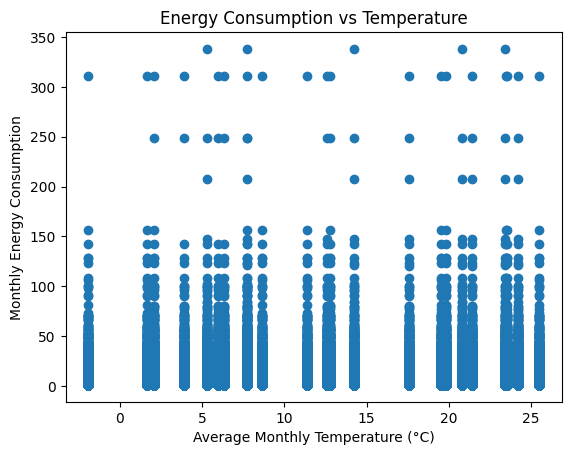

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    final_df['avg_temperature'],
    final_df['energy_consumption']
)
plt.xlabel("Average Monthly Temperature (°C)")
plt.ylabel("Monthly Energy Consumption")
plt.title("Energy Consumption vs Temperature")
plt.show()

The scatter plot shows that energy consumption variance is highest at temperature extremes — both cold and hot months drive elevated demand. Moderate temperatures correspond to lower, more stable usage, consistent with reduced heating and cooling load.

In [25]:
monthly_summary = (
    final_df
    .groupby('year_month', as_index=False)
    .agg({
        'energy_consumption': 'mean',
        'avg_temperature': 'mean'
    })
)

monthly_summary.head()

,year_month,energy_consumption,avg_temperature
0,2022-01-01,2.657702,-1.909677
1,2022-02-01,2.673814,1.667857
2,2022-03-01,2.687202,8.658065
3,2022-04-01,2.693047,11.370000
4,2022-05-01,2.701578,19.541935


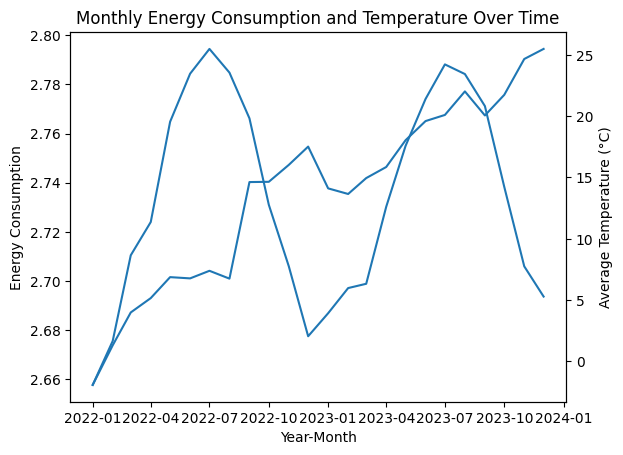

In [26]:
fig, ax1 = plt.subplots()

ax1.plot(
    monthly_summary['year_month'],
    monthly_summary['energy_consumption'],
    label='Energy Consumption'
)
ax1.set_xlabel("Year-Month")
ax1.set_ylabel("Energy Consumption")

ax2 = ax1.twinx()
ax2.plot(
    monthly_summary['year_month'],
    monthly_summary['avg_temperature'],
    label='Average Temperature'
)
ax2.set_ylabel("Average Temperature (°C)")

plt.title("Monthly Energy Consumption and Temperature Over Time")
plt.show()

The dual-axis time series confirms a clear seasonal pattern. Energy consumption peaks align with temperature extremes in winter and summer, while spring and fall — when temperatures are moderate — show reduced demand. The inverse relationship during summer (high temperature, high consumption) and the direct relationship in winter (low temperature, high consumption) together indicate that HVAC load is the primary driver of demand variability.

---

## 6. Next Steps

Several extensions would strengthen this pipeline and analysis:

- **Geographic expansion** — Pull weather data from multiple stations to match the full geographic spread of the energy dataset, rather than a single metro area
- **Additional weather variables** — Incorporate humidity, wind speed, and heating/cooling degree days for a more complete model of demand drivers
- **Predictive modeling** — Use the integrated dataset to train a regression model forecasting monthly energy demand from weather inputs
- **Pipeline automation** — Schedule ingestion and processing using Airflow or Prefect for continuous data updates
- **Sector-level breakdown** — Separate residential, commercial, and industrial consumption to identify which sectors are most temperature-sensitive